## 실습 문제: 균등 분포 난수 생성 및 비교

**설명**: Python의 기본 `random` 모듈과 `NumPy` 라이브러리는 모두 [0, 1) 범위의 균등 분포 난수를 생성하는 기능을 제공합니다. 이 실습의 목표는 `random.uniform()` 함수와 `np.random.rand()` 함수를 각각 사용하여 난수를 생성하고, Matplotlib을 이용해 두 결과의 분포를 히스토그램으로 시각화하여 두 함수가 실제로 유사한 균등 분포를 따르는지 눈으로 확인하는 것입니다.

**요구사항**:
- `random.uniform(0, 1)`을 1000번 반복 호출하여 1000개의 난수가 담긴 리스트를 생성하세요.
- `np.random.rand(1000)`을 호출하여 1000개의 난수로 이루어진 NumPy 배열을 생성하세요.
- Matplotlib의 `subplot` 기능을 사용하여 두 개의 히스토그램을 나란히 그리고, 각 히스토그램에 어떤 함수로 생성된 데이터인지 명시하는 제목을 설정하세요.
- 두 히스토그램의 모양이 특정 구간에 치우치지 않고 전반적으로 평평하게 나타나는지 비교하여 확인하세요.

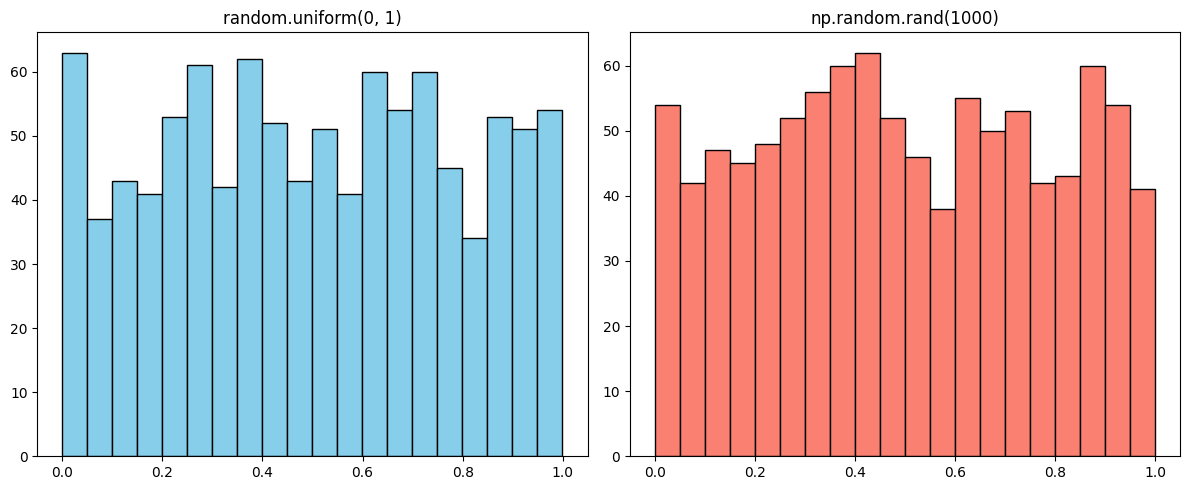

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
# 난수 생성
ranList = [random.uniform(0,1) for _ in range(1000)]
randArray = np.random.rand(1000)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1행 2열

axes[0].hist(ranList, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("random.uniform(0, 1)")

axes[1].hist(randArray, bins=20, color='salmon', edgecolor='black')
axes[1].set_title("np.random.rand(1000)")

plt.tight_layout()
plt.show()



물론입니다. 주어진 문제를 `f(x)` 함수를 직접 구현하는 데 초점을 맞춘 문제로 수정했습니다.

-----

## 실습 문제: 정규분포 확률 밀도 함수(PDF) 구현

**설명**: NumPy와 같은 라이브러리는 정규분포 샘플링을 위한 편리한 함수를 제공하지만, 그 근간이 되는 확률 밀도 함수(PDF, Probability Density Function)를 직접 구현해보는 것은 개념을 이해하는 데 큰 도움이 됩니다. 이 실습에서는 정규분포의 PDF 공식을 코드로 직접 작성하고, 이 함수의 그래프가 실제 데이터 샘플의 분포와 일치하는지 시각적으로 확인합니다.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\Bigl(-\frac{(x-\mu)^2}{2\sigma^2}\Bigr)$$

  - $\\mu$ : 평균 (mean)
  - $ \\sigma\\ $: 표준편차 (standard deviation)

**요구사항**:

  - 주어진 정규분포 PDF 공식을 파이썬 코드로 변환하여 `f(x, mu, sigma)` 함수를 완성하세요. `np.pi`와 `np.exp`를 활용하면 편리합니다.
  - 평균(`μ`) 0, 표준편차(`σ`) 1인 표준 정규분포의 PDF를 계산하도록 함수를 호출하세요.
  - `np.random.normal`로 생성한 샘플 데이터의 히스토그램과 직접 구현한 `f(x)` 함수의 그래프를 함께 그려, 두 결과가 일치하는지 확인합니다.

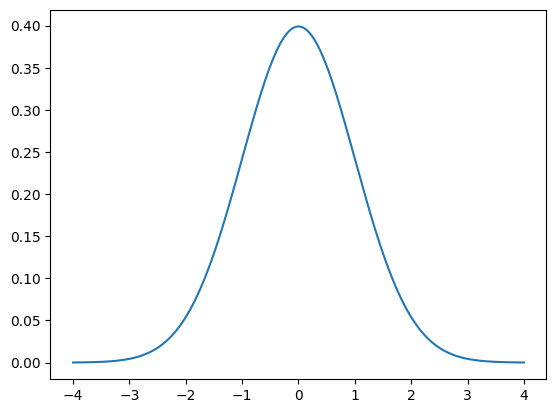

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, mu, sigma):
  """
  정규분포의 확률 밀도 함수(PDF)를 계산합니다.
  x: 확률 변수 값(들)
  mu: 평균
  sigma: 표준편차
  """
  # TODO: 정규분포 PDF 공식을 코드로 구현하세요.
  return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))


mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
y = f(x, mu, sigma)

plt.plot(x, y)

(array([0.00401516, 0.01873739, 0.0816415 , 0.20744971, 0.41088426,
        0.3345963 , 0.19272747, 0.06558087, 0.02141416, 0.00133839]),
 array([-3.71158741, -2.96441835, -2.2172493 , -1.47008025, -0.7229112 ,
         0.02425786,  0.77142691,  1.51859596,  2.26576502,  3.01293407,
         3.76010312]),
 <BarContainer object of 10 artists>)

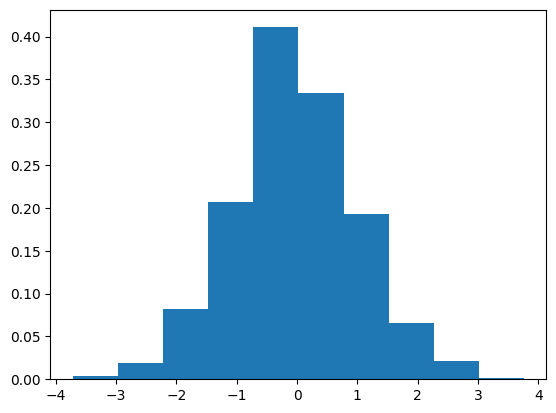

In [ ]:
#정규분포 종모양 normal 대부분 이것사용
samples = np.random.normal(mu, sigma, 1000)
plt.hist(samples, density=True)

In [8]:
np.random.normal(0,1,(100, 32,32)).shape

(100, 32, 32)

In [5]:
np.random.normal(60,10,30)

array([61.25229562, 46.63589133, 67.37309851, 53.73494346, 61.98178309,
       66.67943941, 54.01511172, 62.42085753, 55.68134279, 58.52329796,
       72.41034389, 75.64384312, 49.971242  , 66.44288216, 43.75793044,
       55.50785785, 55.56022893, 49.22446146, 56.27113717, 41.2688724 ,
       65.00073818, 55.29772994, 59.18533953, 63.16080417, 68.14785307,
       49.05627973, 71.89820388, 79.2887068 , 58.78051292, 45.09175589])

## 실습 문제: 정규 분포 난수 시각화

**설명**: NumPy의 `np.random.randn()` 함수는 머신러닝과 통계에서 매우 중요한 표준 정규 분포(평균 0, 표준편차 1)를 따르는 난수를 생성합니다. 이 실습에서는 이 함수를 사용하여 데이터를 생성하고, Matplotlib 히스토그램으로 시각화하여 정규 분포의 특징적인 '종 모양' 곡선을 직접 확인하는 것을 목표로 합니다.

$$f(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}x^2}$$

**요구사항**:
- `np.random.randn(1000)`을 호출하여 표준 정규 분포를 따르는 난수 1000개가 담긴 NumPy 배열을 생성하세요.
- Matplotlib을 사용하여 생성된 데이터의 히스토그램을 그리고, 그래프의 제목을 "Standard Normal Distribution"으로 설정하세요.
- 히스토그램이 데이터의 평균인 0을 중심으로 대칭적인 종 모양(bell shape)을 형성하는지 확인하고, 이전에 만들었던 균등 분포 히스토그램과 어떻게 다른지 생각해 보세요.

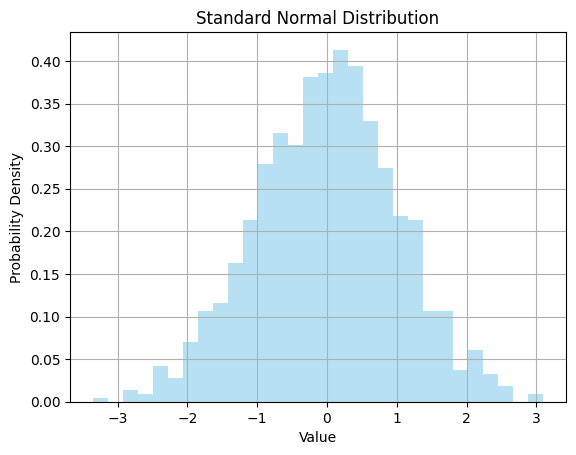

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 정규 분포 난수 1000개 생성
data = np.random.randn(1000)

# 2. 히스토그램 그리기
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue')

# 3. 제목 및 축 라벨
plt.title("Standard Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Probability Density")

# 4. 보조선 및 출력
plt.grid(True)
plt.show()


## 실습 문제: 3차 함수에 노이즈 추가 및 시각화

**설명**: 머신러닝 모델을 훈련할 때, 실제 데이터는 종종 이상적인 함수 관계에 무작위적인 노이즈가 더해진 형태로 나타납니다. 이 실습에서는 3차 함수 $f(x) = x^3 - x^2 + 3$ 라는 '참' 함수를 정의하고, 여기에 정규 분포 노이즈를 추가하여 실제 데이터와 유사한 형태를 만듭니다. 목표는 Matplotlib을 사용하여 원본 함수(선)와 노이즈가 포함된 데이터 포인트(산점도)를 함께 시각화하여 둘의 관계를 파악하는 것입니다.

$$y = x^3 - x^2 + 3$$

**요구사항**:
- `np.linspace`를 사용하여 -5부터 5까지의 범위에서 100개의 균일한 간격의 점으로 `x` 배열을 생성하세요.
- 생성된 `x` 값을 사용하여 3차 함수 $y = x^3 - x^2 + 3$를 계산하여 `y` 배열을 만드세요.
- `np.random.normal` 함수를 사용하여 평균 0, 표준편차 10인 정규 분포 노이즈를 100개 생성하고, 이를 `y` 배열에 더하여 노이즈가 추가된 데이터를 만드세요.
- Matplotlib을 사용하여 원본 $(x, y)$ 데이터는 선 그래프(`plt.plot`)로, 노이즈가 추가된 데이터는 산점도(`plt.scatter`)로 한 플롯에 함께 그리세요. 이를 통해 부드러운 원본 함수와 그 주변에 흩어진 데이터 포인트를 시각적으로 확인할 수 있습니다.

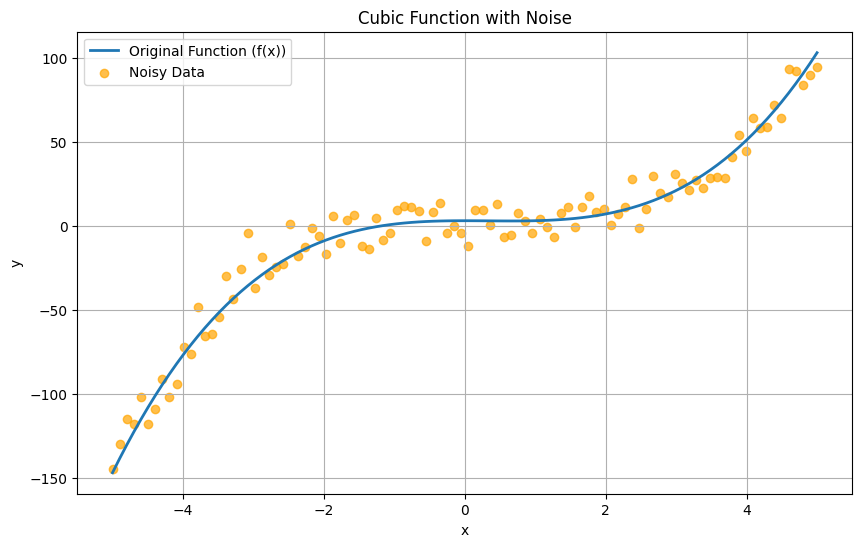

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. x 생성
x = np.linspace(-5, 5, 100)

# 2. 참 함수 y 계산
y_true = x**3 - x**2 + 3

# 3. 노이즈 생성
noise = np.random.normal(loc=0, scale=10, size=100)

# 4. 노이즈가 추가된 y
y_noisy = y_true + noise

# 5. 시각화
plt.figure(figsize=(10, 6))
plt.plot(x, y_true, label='Original Function (f(x))', linewidth=2)
plt.scatter(x, y_noisy, color='orange', alpha=0.7, label='Noisy Data')
plt.title('Cubic Function with Noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()
